# SDE simulation in a periodic potential

Simulate 50 independent trajectories of a one-dimensional stochastic differential equation with Diffrax, then plot the paths.

$$
dX_t = -Ak\sin(kX_t)\,dt + \sigma\,dW_t,
\qquad X_0 = 0.
$$

The drift comes from the periodic potential $V(x)=A[1-\cos(kx)]$. Near $x=0$, the drift is approximately $-Ak^2x$, giving a local Ornstein–Uhlenbeck approximation.


## 1. Imports


In [1]:
import diffrax as dfx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt


## 2. Model parameters

$A$ controls the potential amplitude, $k$ sets its spatial period $2\pi/k$, and $\sigma$ is the constant diffusion coefficient. Each trajectory has its own Brownian motion.


In [2]:
A = 1.0
k = 1.0
sigma = 1.1

n_trajectories = 50


## 3. Potential, drift, and diffusion

The deterministic drift points down the potential gradient:

$$
b(x)=-\frac{dV}{dx}=-Ak\sin(kx).
$$

Diffrax expects the drift and diffusion functions to accept `(t, x, args)`.


In [3]:
def V(x):
    """Periodic potential."""
    return A * (1.0 - jnp.cos(k * x))


def drift(t, x, args):
    """Negative gradient of the potential."""
    return -A * k * jnp.sin(k * x)


def diffusion(t, x, args):
    """Constant diffusion coefficient."""
    return sigma


## 4. Time grid and initial condition

`dt` is the solver step size. `ts` contains the 15,000 times at which the solution is saved; its spacing is approximately 0.0333, so it differs from `dt`.


In [4]:
t0 = 0.0
t1 = 500.0
dt = 0.01
x0 = 0.0

ts = jnp.linspace(t0, t1, 15_000)


## 5. Simulate one trajectory

Construct a Brownian path from a random key, combine the drift and diffusion terms, and integrate with the Euler solver. Return the state values at the saved times.


In [5]:
def simulate_one(key):
    """Simulate one trajectory using the supplied random key."""
    brownian = dfx.VirtualBrownianTree(
        t0=t0,
        t1=t1,
        tol=1e-3,
        shape=(),
        key=key,
    )

    terms = dfx.MultiTerm(
        dfx.ODETerm(drift),
        dfx.ControlTerm(diffusion, brownian),
    )

    solution = dfx.diffeqsolve(
        terms,
        dfx.Euler(),
        t0=t0,
        t1=t1,
        dt0=dt,
        y0=x0,
        saveat=dfx.SaveAt(ts=ts),
        max_steps=100_000,
    )
    return solution.ys


## 6. Generate the ensemble

Split the fixed seed into one key per trajectory. `jax.vmap` applies the simulation to all keys. The resulting array has shape `(n_trajectories, len(ts))`, here `(50, 15000)`.


In [6]:
key = jr.PRNGKey(42)
keys = jr.split(key, n_trajectories)

trajectories = jax.vmap(simulate_one)(keys)
print(f"Trajectories shape: {trajectories.shape}")


Trajectories shape: (50, 15000)


## 7. Plot the trajectories

Each line is an independent realization of the same SDE.


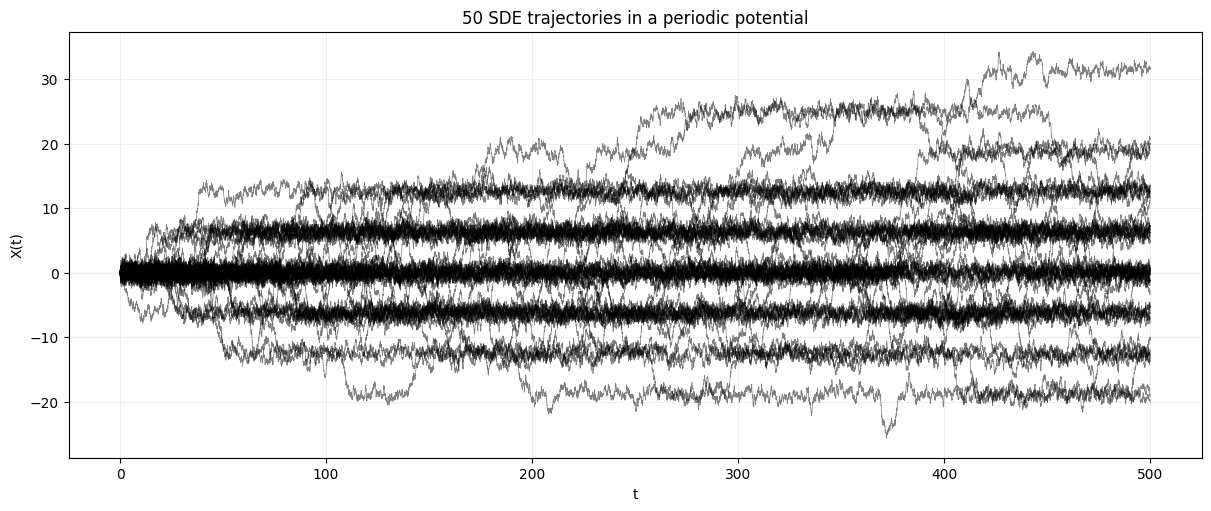

In [7]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

for trajectory in trajectories:
    ax.plot(ts, trajectory, color="black", linewidth=0.5, alpha=0.5)

ax.set(
    xlabel="t",
    ylabel="X(t)",
    title=f"{n_trajectories} SDE trajectories in a periodic potential",
)
ax.grid(alpha=0.2)
plt.show()


## Estimate parameters back via Diffrax

In [8]:
import numpy as np

paths = np.asarray(trajectories)  # shape: (50, 15000)
times = np.asarray(ts)

x = paths[:, :-1]                 # position at the start of each interval
dx = np.diff(paths, axis=1)       # observed change during each interval
delta = np.diff(times)[None, :]   # time between saved observations

k_known = 1.0

# Predicted increment is A * predictor.
predictor = -k_known * np.sin(k_known * x) * delta

# Find the A that best predicts the observed increments.
A_hat = np.sum(predictor * dx) / np.sum(predictor**2)

# What's left after subtracting the predicted drift?
residual = dx - A_hat * predictor

# Residual / sqrt(delta) should have standard deviation sigma.
sigma_hat = np.sqrt(np.mean(residual**2 / delta))

print(f"Estimated A:     {A_hat:.4f}  (simulated value: 1.0)")
print(f"Estimated sigma: {sigma_hat:.4f}  (simulated value: 1.1)")

Estimated A:     0.9063  (simulated value: 1.0)
Estimated sigma: 1.0359  (simulated value: 1.1)
